# Books Sales & Publishing Trend Analysis using Python


## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on a books dataset to identify trends in publishing year, genre distribution, pricing, ratings, and sales.

## Importing Required Libraries
In this section, the necessary Python libraries are imported for data analysis and visualization.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Loading the Dataset
The dataset is loaded into a pandas DataFrame for further analysis.

In [78]:
df = pd.read_excel("Books_Data_Clean.xlsx")

In [46]:
df

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.00,20496.000,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.50,7462.500,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.00,28677.000,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.00,24750.000,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.50,22771.500,7.99,4,Penguin Group (USA) LLC,4750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,1065,2014.0,Gray Mountain,John Grisham,eng,Intermediate,3.52,37379,nonfiction,104.94,62.964,0.99,1268,"Amazon Digital Services, Inc.",106
1066,1066,1989.0,The Power of One,Bryce Courtenay,eng,Excellent,4.34,57312,genre fiction,846.94,508.164,7.99,1270,Random House LLC,106
1067,1067,1930.0,The Maltese Falcon,Dashiell Hammett,eng,Intermediate,3.92,58742,genre fiction,846.94,508.164,7.99,1271,Hachette Book Group,106
1068,1068,2011.0,Night Road,Kristin Hannah,en-US,Excellent,4.17,58028,genre fiction,104.94,62.964,0.99,1272,"Amazon Digital Services, Inc.",106


## Dataset Overview
This section provides an initial understanding of the dataset structure, columns, data types, and summary statistics.

In [47]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [48]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   object 
 3   Author               1070 non-null   object 
 4   language_code        1017 non-null   object 
 5   Author_Rating        1070 non-null   object 
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   object 
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   object 
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), object(6)
mem

In [49]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


## Data Cleaning
The dataset is cleaned by checking for missing values, duplicate records, and inconsistent entries to improve data quality.

In [50]:
df =df[df["Publishing Year"]>1900]

In [51]:
df.isna().sum()

,0
index,0
Publishing Year,0
Book Name,21
Author,0
language_code,49
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [52]:
df.dropna(subset= "Book Name",inplace=True)

/tmp/ipykernel_3735/903798107.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset= "Book Name",inplace=True)


In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.nunique()

,0
index,988
Publishing Year,101
Book Name,987
Author,669
language_code,8
Author_Rating,4
Book_average_rating,133
Book_ratings_count,983
genre,4
gross sales,774


## Exploratory Data Analysis
This section explores patterns and trends in the books dataset using visualizations and statistical analysis.

### Publishing Year Distribution
This chart shows how books are distributed across publishing years.

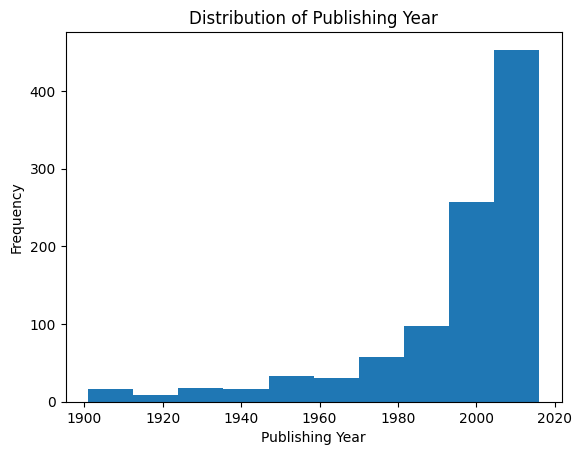

In [55]:
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year")
plt.show()

### Genre Distribution
This chart highlights the frequency of different book genres in the dataset.

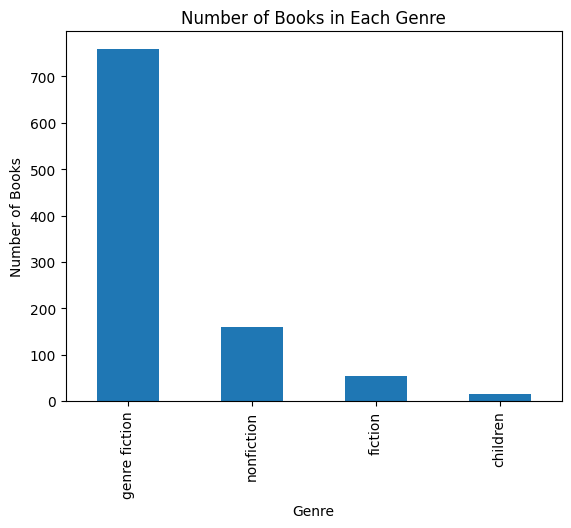

In [56]:
df["genre"].value_counts().plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of Books in Each Genre")
plt.show()

### Top Authors by Average Rating
This analysis identifies authors with the highest average book ratings in the dataset.

In [57]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False).head(10)

,Book_average_rating
Author,
Bill Watterson,4.650
"Bill Watterson, G.B. Trudeau",4.610
J.R.R. Tolkien,4.590
George R.R. Martin,4.560
Sarah J. Maas,4.526
"Hiromu Arakawa, Akira Watanabe",4.490
Cassandra Clare,4.480
Art Spiegelman,4.470
Larry McMurtry,4.470


### Genre vs Ratings Count
This boxplot compares the distribution of book ratings count across different genres.

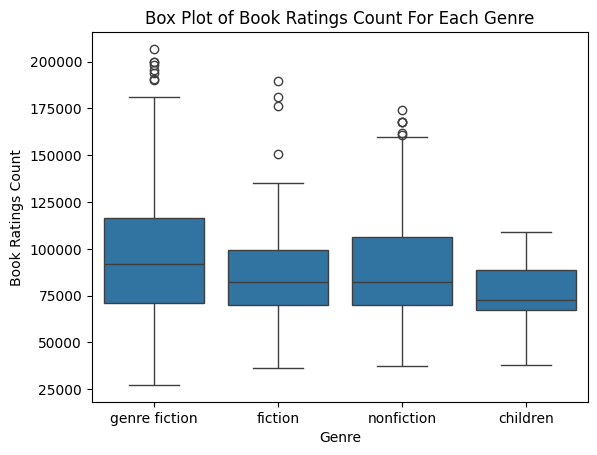

In [58]:
sns.boxplot(x="genre", y="Book_ratings_count", data = df)
plt.xlabel("Genre")
plt.ylabel("Book Ratings Count")
plt.title("Box Plot of Book Ratings Count For Each Genre")
plt.show()

### Price vs Sales Analysis
This visualization helps understand the relationship between book price and sales.

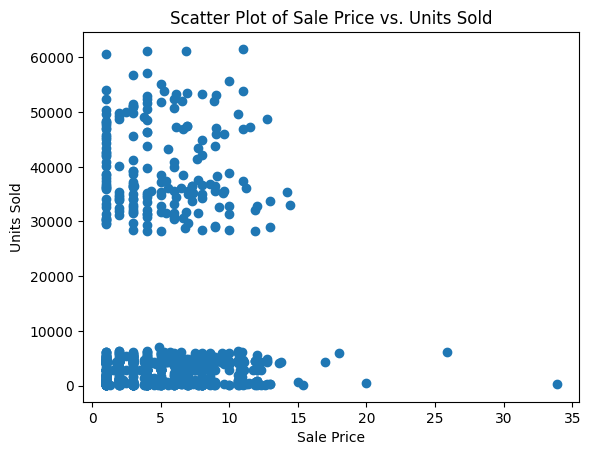

In [59]:
plt.scatter(df["sale price"], df["units sold"] )
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Scatter Plot of Sale Price vs. Units Sold")
plt.show()

### Language Distribution
This chart shows the proportion of books available in different languages.

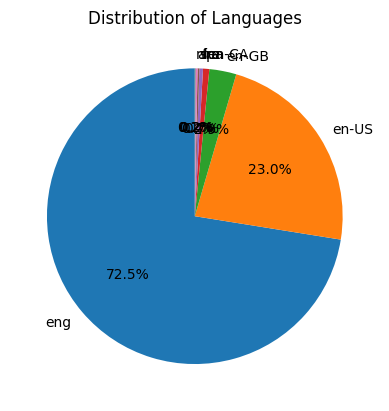

In [81]:
language_counts = df["language_code"].value_counts()
plt.pie(language_counts, labels=language_counts.index, startangle=90, autopct="%1.1f%%")
plt.title("Distribution of Languages")
plt.show()

### Publisher Revenue Analysis
This section shows the publishers generating the highest revenue.

In [62]:
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending=False)

,publisher revenue
Publisher,
Penguin Group (USA) LLC,191581.104
Random House LLC,174956.244
"Amazon Digital Services, Inc.",141767.772
HarperCollins Publishers,121769.814
Hachette Book Group,107410.968
Simon and Schuster Digital Sales Inc,46858.206
Macmillan,31249.830
HarperCollins Publishing,2830.806
HarperCollins Christian Publishing,2135.670


### Genre-wise Average Units Sold
This analysis compares the average number of units sold across different genres.

In [65]:
category_subscribers_mean=df.groupby("genre")["units sold"].mean()
category_subscribers_mean

,units sold
genre,
children,19874.533333
fiction,9568.555556
genre fiction,9696.735178
nonfiction,9816.618750


### Language-wise Book Count
This section shows the number of books available in each language.

In [66]:
df.groupby("language_code").size().sort_values(ascending=False)

,0
language_code,
eng,670
en-US,226
en-GB,29
en-CA,7
fre,4
ara,2
spa,2
nl,1


### Average Rating vs Ratings Count
This scatter plot helps analyze the relationship between book ratings and the number of ratings received.

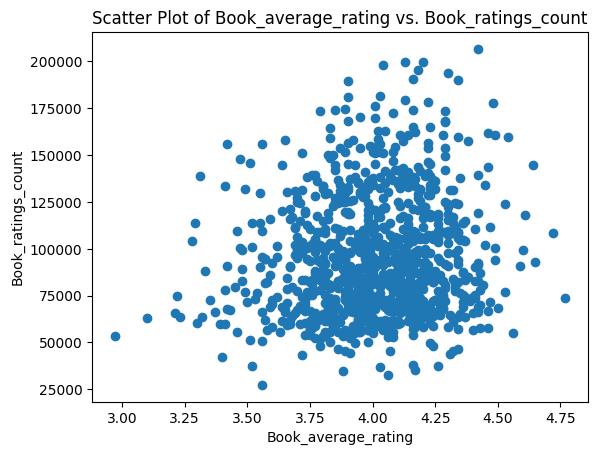

In [73]:
plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])
plt.xlabel("Book_average_rating")
plt.ylabel("Book_ratings_count")
plt.title("Scatter Plot of Book_average_rating vs. Book_ratings_count")
plt.show()

### Gross Sales by Author
This analysis calculates total gross sales contributed by each author.

In [74]:
total_gross_sales_by_author= df.groupby("Author")["gross sales"].sum().sort_values(ascending=False)

### Top Authors by Gross Sales
This chart shows the authors with the highest total gross sales.

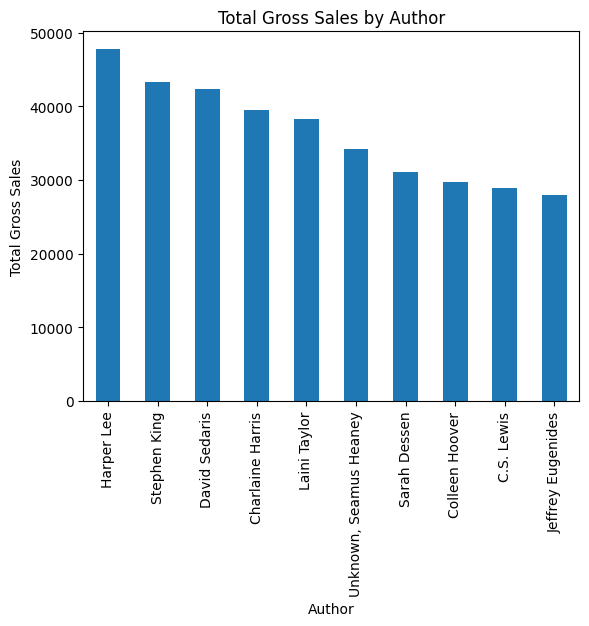

In [75]:
total_gross_sales_by_author.sort_values(ascending=False).head(10).plot(kind="bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Total Gross Sales by Author")
plt.show()

### Author Rating vs Units Sold
This boxplot helps compare book sales across different author rating categories.### Author Rating vs Units Sold
This boxplot helps compare book sales across different author rating categories.

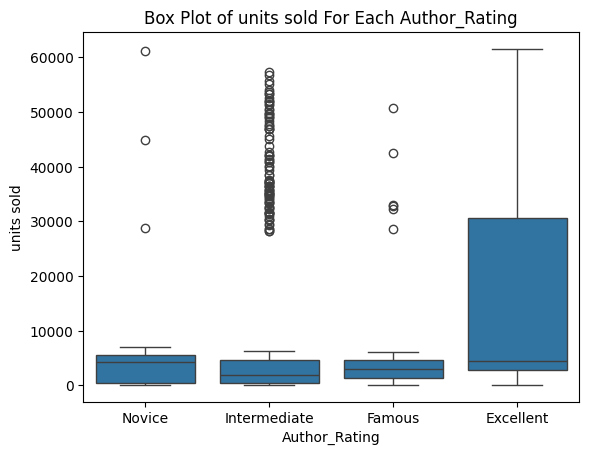

In [76]:
sns.boxplot(x="Author_Rating", y="units sold", data = df)
plt.xlabel("Author_Rating")
plt.ylabel("units sold")
plt.title("Box Plot of units sold For Each Author_Rating")
plt.show()

### Publishing Year vs Units Sold
This line chart shows how total units sold vary across publishing years.

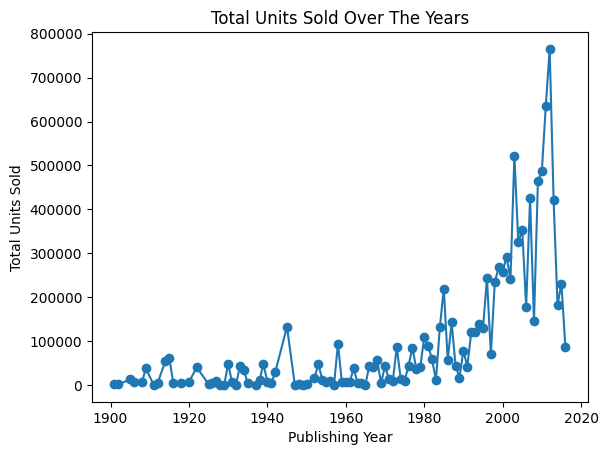

In [77]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line", marker = "o")
plt.xlabel("Publishing Year")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold Over The Years")
plt.show()
#

## Key Insights
- Most books in the dataset were published after the year 2000.
- Certain genres appear more frequently than others, indicating higher representation in the dataset.
- The relationship between sale price and units sold provides useful insights into pricing behavior.
- Some authors and publishers contribute more significantly to total sales and revenue.
- Language and author rating also show noticeable variation in book performance.

## Conclusion
This project demonstrates the use of Python for data cleaning, exploratory data analysis, and visualization. By analyzing publishing trends, genre distribution, pricing, ratings, and sales, the project provides meaningful insights into the books dataset and highlights the importance of structured data analysis.